# Contrastive Vision Agent Pretraining

This notebook implements the paper's Vision Agent pretraining stage for Vision-Driven MARL on JAX-LOB. It learns level-centered contextual LOB tokens from normalized Top-10 order book snapshots. Two augmented views of the same snapshot are positives and other batch snapshots are negatives.

Input tensors are expected to have shape `[N, 10, 3, 2]`, where each snapshot stores `[Gap, LogVol, CumVol]` across ask/bid sides. The encoder output is `Z_t = [z_t,1, ..., z_t,K]` with shape `[N, K, d]`. Token `k` remains aligned with LOB level `k`, but also receives local context from neighboring levels through the production `VisionAgent`. Global InfoNCE is applied only to the default pooled output `mean(Z_t, axis=level)`, and the saved Vision Agent params remain compatible with downstream reliability/fusion use.

## 1. Setup

JAX is allowed to select the CUDA backend when it is available, so pretraining uses the GPU on machines with a working CUDA-backed JAX install. Set `VIT_MARL_FORCE_CPU=1` before running the notebook only when you explicitly want a CPU fallback.

In [13]:
import os

if os.getenv("VIT_MARL_FORCE_CPU", "0") == "1":
    os.environ.setdefault("JAX_PLATFORMS", "cpu")
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
os.environ.setdefault("XDG_CACHE_HOME", "/tmp")

from pathlib import Path
import json
import time

import numpy as np
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp
from flax import linen as nn
from flax import serialization
from flax.training import train_state
import optax

from gymnax_exchange.networks.vision_agent import VisionAgent

DATA_SOURCE = "main_env_rollout"  # recommended: main_env_rollout | cached | fixed_time_loader
REGENERATE_DATA = os.getenv("VIT_MARL_REGENERATE_DATA", "1") == "1"
DATA_PATH = "vision_obs_all.npy"
METADATA_PATH = "vision_obs_all_metadata.json"
OUTPUT_DIR = Path("outputs")

# PPO/main-training matched env settings for VisionAgent pretrain data collection.
MAIN_EP_TYPE = "fixed_steps"
MAIN_EPISODE_TIME = 50
MAIN_START_RESOLUTION = 50
MAIN_N_DATA_MSG_PER_STEP = 100
MAIN_EXEC_OBSERVATION_SPACE = "execution_policy"
MAIN_EXEC_ACTION_SPACE = "policy_blending"
MAIN_N_LEVELS = 10
MAIN_FEATURE_SHAPE = (10, 3, 2)

# Rollout collection settings. Increase NUM_ENVS for a larger cache once the path is verified.
ROLLOUT_NUM_ENVS = int(os.getenv("VIT_MARL_PRETRAIN_NUM_ENVS", "128"))
ROLLOUT_NUM_STEPS = int(os.getenv("VIT_MARL_PRETRAIN_NUM_STEPS", str(MAIN_EPISODE_TIME)))
ACTION_COLLECTION_MODE = os.getenv("VIT_MARL_ACTION_COLLECTION_MODE", "random_legal")

EPOCHS = int(os.getenv("VIT_MARL_CL_EPOCHS", "200"))
BATCH_SIZE = 64
TEMPERATURE = 0.1
EMBED_DIM = 128
HIDDEN_SIZE = 128
CONTEXT_ALPHA_INIT = 0.1
LEARNABLE_ALPHA = True
SEED = 0
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-4

JITTER_STD = 0.03
LEVEL_KEEP_PROB = 0.9
FEATURE_KEEP_PROB = 0.9

OUTPUT_DIR.mkdir(exist_ok=True)

print("JAX version:", jax.__version__)
print("JAX backend:", jax.default_backend())
print("JAX devices:", jax.devices())
print("Data source:", DATA_SOURCE)
print("Regenerate data:", REGENERATE_DATA)
print("Epochs:", EPOCHS)



JAX version: 0.10.0
JAX backend: gpu
JAX devices: [CudaDevice(id=0)]
Data source: main_env_rollout
Regenerate data: True
Epochs: 200


## 2. Data Loading

Default `DATA_SOURCE = "main_env_rollout"` collects `obs[Execution]["vision_obs"]` through the same `MARLEnv.reset/step` path used by PPO/main training. This avoids the old fixed-time regeneration mismatch: `window_length` is not equivalent to `episode_time` under `fixed_steps`.

Use `DATA_SOURCE = "cached"` only when `vision_obs_all.npy` has matching metadata in `vision_obs_all_metadata.json`. The optional `DATA_SOURCE = "fixed_time_loader"` path is kept only for broad pretraining or ablation and is explicitly marked as not PPO-matched in metadata.



In [ ]:
def expected_main_env_metadata():
    return {
        "data_source": "main_env_rollout",
        "ep_type": MAIN_EP_TYPE,
        "episode_time": int(MAIN_EPISODE_TIME),
        "start_resolution": int(MAIN_START_RESOLUTION),
        "n_data_msg_per_step": int(MAIN_N_DATA_MSG_PER_STEP),
        "observation_space": MAIN_EXEC_OBSERVATION_SPACE,
        "action_space": MAIN_EXEC_ACTION_SPACE,
        "n_levels": int(MAIN_N_LEVELS),
        "feature_shape": list(MAIN_FEATURE_SHAPE),
        "dataset_standardization": False,
        "normalization": "lob_feature_pipeline_only",
        "pretrain_data_matches_ppo": True,
    }


def validate_metadata(metadata, expected, *, metadata_path):
    missing = [key for key in expected if key not in metadata]
    mismatched = [
        (key, metadata.get(key), expected[key])
        for key in expected
        if key in metadata and metadata.get(key) != expected[key]
    ]
    if missing or mismatched:
        detail = {
            "missing": missing,
            "mismatched": mismatched,
            "metadata_path": str(metadata_path),
        }
        raise ValueError(
            "Cached vision observations do not match PPO/main-training data config. "
            f"Regenerate with DATA_SOURCE='main_env_rollout'. Details: {detail}"
        )


def load_metadata(metadata_path, expected):
    if not metadata_path.exists():
        raise FileNotFoundError(
            f"Missing metadata file: {metadata_path}. "
            "Regenerate vision observations before training from cache."
        )
    with metadata_path.open("r", encoding="utf-8") as f:
        metadata = json.load(f)
    validate_metadata(metadata, expected, metadata_path=metadata_path)
    return metadata


def write_metadata(metadata_path, metadata):
    with metadata_path.open("w", encoding="utf-8") as f:
        json.dump(metadata, f, indent=2)


def validate_vision_obs_all(vision_obs_all):
    vision_obs_all = np.asarray(vision_obs_all, dtype=np.float32)
    if vision_obs_all.ndim != 4 or tuple(vision_obs_all.shape[1:]) != MAIN_FEATURE_SHAPE:
        raise ValueError(f"Expected `[N, 10, 3, 2]`, got {vision_obs_all.shape}")
    if vision_obs_all.dtype != np.float32:
        raise TypeError(f"Expected float32 vision tensor, got {vision_obs_all.dtype}")
    if not np.isfinite(vision_obs_all).all():
        raise ValueError("Vision tensor contains NaN or Inf values")
    return vision_obs_all


def make_main_env_rollout_metadata(num_envs, num_steps):
    metadata = expected_main_env_metadata()
    metadata.update({
        "action_collection_mode": ACTION_COLLECTION_MODE,
        "rollout_num_envs": int(num_envs),
        "rollout_num_steps": int(num_steps),
        "seed": int(SEED),
    })
    return metadata


def ensure_market_making_import_alias():
    import importlib.util
    import sys

    module_name = "gymnax_exchange.jaxen.mm_env"
    if module_name in sys.modules:
        return
    mm_env_path = Path.cwd() / "gymnax_exchange" / "jaxen" / "[marketmaker]mm_env.py"
    if not mm_env_path.exists():
        raise FileNotFoundError(f"Cannot locate MarketMakingAgent module: {mm_env_path}")
    spec = importlib.util.spec_from_file_location(module_name, mm_env_path)
    module = importlib.util.module_from_spec(spec)
    sys.modules[module_name] = module
    spec.loader.exec_module(module)


def make_main_training_like_env(seed):
    ensure_market_making_import_alias()
    from gymnax_exchange.jaxen.marl_env import MARLEnv
    from gymnax_exchange.jaxob.jaxob_config import (
        Execution_EnvironmentConfig,
        MarketMaking_EnvironmentConfig,
        MultiAgentConfig,
        World_EnvironmentConfig,
    )

    world_config = World_EnvironmentConfig(
        seed=int(seed),
        ep_type=MAIN_EP_TYPE,
        episode_time=int(MAIN_EPISODE_TIME),
        start_resolution=int(MAIN_START_RESOLUTION),
        n_data_msg_per_step=int(MAIN_N_DATA_MSG_PER_STEP),
    )
    agent_configs = {
        "MarketMaking": MarketMaking_EnvironmentConfig(
            action_space="fixed_quants",
            inv_penalty="quadratic",
            reward_space="spooner",
            reference_price_portfolio_value="best_bid_ask",
            skew_multiplier=10,
        ),
        "Execution": Execution_EnvironmentConfig(
            action_space=MAIN_EXEC_ACTION_SPACE,
            observation_space=MAIN_EXEC_OBSERVATION_SPACE,
            task_size=600,
            reward_lambda=0.5,
            doom_price_penalty=0.1,
        ),
    }
    multi_agent_config = MultiAgentConfig(
        number_of_agents_per_type=[1, 1],
        dict_of_agents_configs=agent_configs,
        world_config=world_config,
    )
    key = jax.random.PRNGKey(int(seed))
    env = MARLEnv(key=key, multi_agent_config=multi_agent_config)
    return env, env.default_params, multi_agent_config


def sample_actions_for_single_env(env, key):
    if ACTION_COLLECTION_MODE != "random_legal":
        raise ValueError(f"Unsupported ACTION_COLLECTION_MODE: {ACTION_COLLECTION_MODE}")
    subkeys = jax.random.split(key, len(env.action_spaces))
    actions = []
    for subkey, space, n_agents in zip(
        subkeys,
        env.action_spaces,
        env.multi_agent_config.number_of_agents_per_type,
    ):
        if int(n_agents) == 1:
            actions.append(space.sample(subkey))
        else:
            agent_keys = jax.random.split(subkey, int(n_agents))
            actions.append(jax.vmap(space.sample)(agent_keys))
    return actions


def execution_vision_obs_from_obs(env, obs):
    execution_type_index = env.type_names.index("EXE")
    return obs[execution_type_index]["vision_obs"]


def collect_main_env_rollout_vision_observations(num_envs=ROLLOUT_NUM_ENVS, num_steps=ROLLOUT_NUM_STEPS):
    env, env_params, _ = make_main_training_like_env(SEED)
    rng = jax.random.PRNGKey(SEED)
    rng, reset_key = jax.random.split(rng)
    reset_keys = jax.random.split(reset_key, int(num_envs))

    batched_reset = jax.jit(jax.vmap(env.reset, in_axes=(0, None)))
    obs, state = batched_reset(reset_keys, env_params)
    jax.block_until_ready(state)

    def single_step(state_i, key_i):
        actions_i = sample_actions_for_single_env(env, key_i)
        return env.step(key_i, state_i, actions_i, env_params)

    batched_step = jax.jit(jax.vmap(single_step, in_axes=(0, 0)))

    def scan_body(carry, _):
        state_t, obs_t, rng_t = carry
        current_vision = execution_vision_obs_from_obs(env, obs_t)
        rng_t, step_key = jax.random.split(rng_t)
        step_keys = jax.random.split(step_key, int(num_envs))
        next_obs, next_state, rewards, dones, infos = batched_step(state_t, step_keys)
        return (next_state, next_obs, rng_t), current_vision

    (final_state, final_obs, _), vision_traj = jax.lax.scan(
        scan_body,
        (state, obs, rng),
        None,
        length=int(num_steps),
    )
    jax.block_until_ready(final_state)

    vision_obs_all = np.asarray(vision_traj, dtype=np.float32).reshape(-1, *MAIN_FEATURE_SHAPE)
    vision_obs_all = validate_vision_obs_all(vision_obs_all)
    metadata = make_main_env_rollout_metadata(num_envs=num_envs, num_steps=num_steps)
    validate_metadata(metadata, expected_main_env_metadata(), metadata_path=Path(METADATA_PATH))
    return vision_obs_all, metadata


def regenerate_fixed_time_loader_vision_observations(
    max_windows=None,
    process_window_msgs=False,
    max_msgs_per_window=100,
):
    """Legacy broad-pretrain loader. Not PPO matched; keep only for ablation."""
    from gymnax_exchange.jaxob import JaxOrderBookArrays as job
    from gymnax_exchange.jaxob.jaxob_config import (
        Execution_EnvironmentConfig,
        JAXLOB_Configuration,
        World_EnvironmentConfig,
    )
    from gymnax_exchange.jaxen.StatesandParams import WorldState
    from gymnax_exchange.jaxen.vision_env import ExecutionAgent
    from lobster_loader import LoadLOBSTER_resample

    repo_root = Path.cwd()
    loader = LoadLOBSTER_resample(
        datapath=str(repo_root),
        atpath=str(repo_root),
        stock="AMZN",
        time_period="2012-06-21",
        n_Levels=10,
        n_data_msg_per_step=MAIN_N_DATA_MSG_PER_STEP,
        day_start=34200,
        day_end=57600,
        type_="fixed_time",
        window_length=1800,
        window_resolution=60,
    )
    msgs, starts, ends, snapshots, _ = loader.run_loading()

    lob_cfg = JAXLOB_Configuration()
    world_config = World_EnvironmentConfig(n_data_msg_per_step=MAIN_N_DATA_MSG_PER_STEP)
    exec_config = Execution_EnvironmentConfig(
        action_space="simplest_case",
        observation_space=MAIN_EXEC_OBSERVATION_SPACE,
    )
    agent = ExecutionAgent(cfg=exec_config, world_config=world_config)
    scan_book = jax.jit(job.scan_through_entire_array, static_argnums=(0,))

    n_windows_total = min(len(starts), len(ends), len(snapshots))
    n_windows = n_windows_total if max_windows is None else min(n_windows_total, max_windows)
    rng = jax.random.PRNGKey(SEED)
    out = []

    for i in range(n_windows):
        rng, subkey = jax.random.split(rng)
        now = jnp.array([34200 + i * 60, 0])
        init_orders = job.init_msgs_from_l2(lob_cfg, snapshots[i], time=now)
        asks = job.init_orderside(lob_cfg.nOrders)
        bids = job.init_orderside(lob_cfg.nOrders)
        trades = (jnp.ones((lob_cfg.nTrades, 8)) * -1).astype(jnp.int32)
        asks, bids, trades = scan_book(lob_cfg, subkey, init_orders, (asks, bids, trades))

        if process_window_msgs:
            start_i = int(starts[i])
            end_i = int(ends[i])
            actual_len = min(max(0, end_i - start_i), max_msgs_per_window)
            if actual_len > 0:
                rng, subkey = jax.random.split(rng)
                raw_slice = msgs[start_i:start_i + actual_len]
                pad_len = max_msgs_per_window - actual_len
                if pad_len > 0:
                    padding = jnp.zeros((pad_len, raw_slice.shape[1]), dtype=raw_slice.dtype)
                    window_msgs = jnp.concatenate([raw_slice, padding], axis=0)
                else:
                    window_msgs = raw_slice
                asks, bids, trades = scan_book(lob_cfg, subkey, window_msgs, (asks, bids, trades))

        best_bid, best_ask = job.get_best_bid_and_ask_inclQuants(lob_cfg, asks, bids)
        mid_price = (best_ask[0] + best_bid[0]) / 2
        world_state = WorldState(
            ask_raw_orders=asks,
            bid_raw_orders=bids,
            trades=trades,
            init_time=now,
            window_index=i,
            max_steps_in_episode=100,
            start_index=int(starts[i]),
            step_counter=0,
            best_bids=jnp.array([best_bid]),
            best_asks=jnp.array([best_ask]),
            time=now,
            order_id_counter=0,
            mid_price=mid_price,
            delta_time=0.0,
        )
        out.append(np.asarray(agent._get_obs_vision(world_state, normalize=True)))

    metadata = {
        "data_source": "fixed_time_loader",
        "loader_type": "fixed_time",
        "window_length": 1800,
        "window_resolution": 60,
        "n_data_msg_per_step": int(MAIN_N_DATA_MSG_PER_STEP),
        "observation_space": MAIN_EXEC_OBSERVATION_SPACE,
        "action_space": "simplest_case",
        "n_levels": int(MAIN_N_LEVELS),
        "feature_shape": list(MAIN_FEATURE_SHAPE),
        "dataset_standardization": False,
        "normalization": "lob_feature_pipeline_only",
        "pretrain_data_matches_ppo": False,
        "warning": "Use only for broad pretrain or ablation, not PPO-matched checkpointing.",
    }
    return validate_vision_obs_all(np.stack(out, axis=0)), metadata


data_path = Path(DATA_PATH)
metadata_path = Path(METADATA_PATH)
expected_metadata = expected_main_env_metadata()

if DATA_SOURCE not in {"main_env_rollout", "cached", "fixed_time_loader"}:
    raise ValueError(f"Unsupported DATA_SOURCE: {DATA_SOURCE}")

if DATA_SOURCE == "main_env_rollout":
    if REGENERATE_DATA:
        start_time = time.time()
        vision_obs_all, data_metadata = collect_main_env_rollout_vision_observations()
        np.save(data_path, vision_obs_all)
        write_metadata(metadata_path, data_metadata)
        print(f"Collected PPO-matched rollout data in {time.time() - start_time:.2f}s")
    else:
        data_metadata = load_metadata(metadata_path, expected_metadata)
        vision_obs_all = np.load(data_path)
elif DATA_SOURCE == "cached":
    data_metadata = load_metadata(metadata_path, expected_metadata)
    vision_obs_all = np.load(data_path)
else:
    if not REGENERATE_DATA:
        fixed_time_expected = {
            "data_source": "fixed_time_loader",
            "pretrain_data_matches_ppo": False,
            "dataset_standardization": False,
            "normalization": "lob_feature_pipeline_only",
            "feature_shape": list(MAIN_FEATURE_SHAPE),
        }
        data_metadata = load_metadata(metadata_path, fixed_time_expected)
        vision_obs_all = np.load(data_path)
    else:
        vision_obs_all, data_metadata = regenerate_fixed_time_loader_vision_observations()
        np.save(data_path, vision_obs_all)
        write_metadata(metadata_path, data_metadata)
        print("Generated fixed_time_loader data; this cache is not PPO matched.")

vision_obs_all = validate_vision_obs_all(vision_obs_all)
validate_metadata(data_metadata, expected_metadata, metadata_path=metadata_path) if data_metadata.get("pretrain_data_matches_ppo") else None

print("vision_obs_all shape:", vision_obs_all.shape)
print("dtype:", vision_obs_all.dtype)
print("min/max:", float(vision_obs_all.min()), float(vision_obs_all.max()))
print("metadata:", json.dumps(data_metadata, indent=2))




self.datapath /mnt/d/ViT-MARL-main/ViT-MARL/data/AMZN/2012June_oneday/
found 1 message files
found 1 book files
Loading cached arrays from /mnt/d/ViT-MARL-main/ViT-MARL/saved_npz/lobster_AMZN_2012June_oneday_10_fixed_steps_50_50_100_34200_57600.npz
START:  pre-reset in the initialization
pre-reset will be saved to  /mnt/d/ViT-MARL-main/ViT-MARL/pre_reset_states/ResetState_window_resolution_50_eptype_fixed_steps_depth_10_stock_AMZN_windowidx_-1_nMsgPerStep_100_episode_time_50_TimePeriod_2012June_oneday.pkl
LOADING STATES FROM PKL...
DONE: pre-reset in the initialization


## 3. LOB-Normalized Input and Visualization

`vision_obs_all` is already produced by the repo's LOB feature normalization pipeline. The pretraining notebook intentionally does not apply dataset-level mean/std standardization, so the VisionAgent sees the same input distribution here as it sees during PPO/main training.

Using LOB feature pipeline output directly; dataset standardization disabled.
x_data shape: (6400, 10, 3, 2)
x_data dtype: float32
x_data min/max: 0.0 623.5


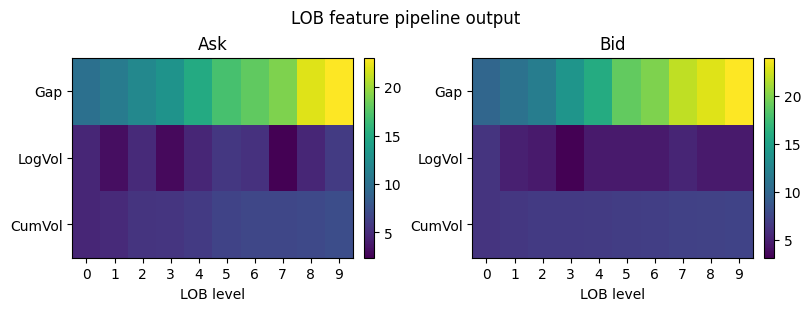

In [ ]:
x_data = np.asarray(vision_obs_all, dtype=np.float32)

if x_data.ndim != 4 or x_data.shape[1:] != (10, 3, 2):
    raise ValueError(f"Expected x_data shape `[N, 10, 3, 2]`, got {x_data.shape}")
if x_data.dtype != np.float32:
    raise TypeError(f"Expected x_data dtype float32, got {x_data.dtype}")

print("Using LOB feature pipeline output directly; dataset standardization disabled.")
print("x_data shape:", x_data.shape)
print("x_data dtype:", x_data.dtype)
print("x_data min/max:", float(x_data.min()), float(x_data.max()))


def plot_lob_snapshot(snapshot, title):
    feature_names = ["Gap", "LogVol", "CumVol"]
    side_names = ["Ask", "Bid"]
    fig, axes = plt.subplots(1, 2, figsize=(8, 3), constrained_layout=True)
    for side_idx, ax in enumerate(axes):
        image = snapshot[:, :, side_idx].T
        im = ax.imshow(image, aspect="auto", cmap="viridis")
        ax.set_title(side_names[side_idx])
        ax.set_xlabel("LOB level")
        ax.set_xticks(range(snapshot.shape[0]))
        ax.set_yticks(range(len(feature_names)))
        ax.set_yticklabels(feature_names)
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.suptitle(title)
    return fig


plot_lob_snapshot(x_data[0], "LOB feature pipeline output")
plt.show()

## 4. Vision Agent and InfoNCE

The notebook now pretrains the same `VisionAgent` class used by the MARL pipeline. The encoder returns level-centered contextual tokens when `return_tokens=True`, and its default call returns the pooled vector `jnp.mean(level_tokens, axis=-2)`. InfoNCE is applied to that default pooled output, so no projection head or alternate output interface is introduced.

In [ ]:
def l2_normalize(x, eps=1e-8):
    return x / jnp.maximum(jnp.linalg.norm(x, axis=-1, keepdims=True), eps)


def info_nce_loss(z_a, z_b, temperature=TEMPERATURE):
    z_a = l2_normalize(z_a)
    z_b = l2_normalize(z_b)
    logits = (z_a @ z_b.T) / temperature
    labels = jnp.arange(logits.shape[0])
    loss_a = optax.softmax_cross_entropy_with_integer_labels(logits, labels).mean()
    loss_b = optax.softmax_cross_entropy_with_integer_labels(logits.T, labels).mean()
    acc_a = (jnp.argmax(logits, axis=1) == labels).mean()
    acc_b = (jnp.argmax(logits.T, axis=1) == labels).mean()
    return 0.5 * (loss_a + loss_b), 0.5 * (acc_a + acc_b)


def augment_batch(rng, x):
    rng_jitter, rng_level, rng_feature = jax.random.split(rng, 3)
    jitter = JITTER_STD * jax.random.normal(rng_jitter, x.shape, dtype=x.dtype)
    level_mask = jax.random.bernoulli(
        rng_level,
        LEVEL_KEEP_PROB,
        shape=(x.shape[0], x.shape[1], 1, 1),
    )
    feature_mask = jax.random.bernoulli(
        rng_feature,
        FEATURE_KEEP_PROB,
        shape=(x.shape[0], 1, x.shape[2], 1),
    )
    return (x + jitter) * level_mask.astype(x.dtype) * feature_mask.astype(x.dtype)


model = VisionAgent(
    embed_dim=EMBED_DIM,
    hidden_size=HIDDEN_SIZE,
    context_alpha_init=CONTEXT_ALPHA_INIT,
    learnable_alpha=LEARNABLE_ALPHA,
)
rng = jax.random.PRNGKey(SEED)
rng, init_rng = jax.random.split(rng)
init_batch = jnp.asarray(x_data[: min(8, len(x_data))])
params = model.init(init_rng, init_batch)["params"]
optimizer = optax.adamw(learning_rate=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
state = train_state.TrainState.create(apply_fn=model.apply, params=params, tx=optimizer)

test_tokens = model.apply(
    {"params": state.params},
    init_batch,
    return_tokens=True,
)
test_embedding = model.apply({"params": state.params}, init_batch)
if not jnp.allclose(test_embedding, jnp.mean(test_tokens, axis=-2), atol=1e-5):
    raise RuntimeError("VisionAgent default output must equal mean-pooled level tokens")
print("level token shape:", test_tokens.shape)
print("pooled embedding shape:", test_embedding.shape)
print("context alpha:", float(jax.nn.sigmoid(state.params["context_alpha_logit"])))

level token shape: (8, 10, 128)
pooled embedding shape: (8, 128)
context alpha: 0.10000000149011612


## 5. Training

In [ ]:
@jax.jit
def train_step(state, batch, rng):
    rng_a, rng_b = jax.random.split(rng)
    view_a = augment_batch(rng_a, batch)
    view_b = augment_batch(rng_b, batch)

    def loss_fn(params):
        z_a = state.apply_fn({"params": params}, view_a, train=True)
        z_b = state.apply_fn({"params": params}, view_b, train=True)
        return info_nce_loss(z_a, z_b)

    (loss, acc), grads = jax.value_and_grad(loss_fn, has_aux=True)(state.params)
    state = state.apply_gradients(grads=grads)
    return state, loss, acc


def iter_batches(array, rng_key, batch_size):
    n = array.shape[0]
    perm = np.asarray(jax.random.permutation(rng_key, n))
    for start in range(0, n, batch_size):
        idx = perm[start:start + batch_size]
        if len(idx) < 2:
            continue
        yield jnp.asarray(array[idx])


loss_history = []
acc_history = []
start_time = time.time()

for epoch in range(1, EPOCHS + 1):
    rng, epoch_rng = jax.random.split(rng)
    epoch_losses = []
    epoch_accs = []
    for batch in iter_batches(x_data, epoch_rng, BATCH_SIZE):
        rng, step_rng = jax.random.split(rng)
        state, loss, acc = train_step(state, batch, step_rng)
        epoch_losses.append(float(loss))
        epoch_accs.append(float(acc))

    mean_loss = float(np.mean(epoch_losses))
    mean_acc = float(np.mean(epoch_accs))
    loss_history.append(mean_loss)
    acc_history.append(mean_acc)
    if epoch == 1 or epoch == EPOCHS or epoch % max(1, EPOCHS // 10) == 0:
        print(f"epoch {epoch:03d}/{EPOCHS} loss={mean_loss:.4f} retrieval_acc={mean_acc:.3f}")

elapsed = time.time() - start_time
print(f"training time: {elapsed:.1f}s")
if not np.isfinite(loss_history[-1]):
    raise RuntimeError("Final InfoNCE loss is not finite")

epoch 001/200 loss=3.4647 retrieval_acc=0.384
epoch 020/200 loss=1.0242 retrieval_acc=0.776
epoch 040/200 loss=0.5836 retrieval_acc=0.880
epoch 060/200 loss=0.4870 retrieval_acc=0.905
epoch 080/200 loss=0.4371 retrieval_acc=0.917
epoch 100/200 loss=0.3758 retrieval_acc=0.934
epoch 120/200 loss=0.3416 retrieval_acc=0.944
epoch 140/200 loss=0.3184 retrieval_acc=0.944
epoch 160/200 loss=0.3060 retrieval_acc=0.948
epoch 180/200 loss=0.2638 retrieval_acc=0.960
epoch 200/200 loss=0.2628 retrieval_acc=0.957
training time: 114.8s


## 6. Embedding Diagnostics

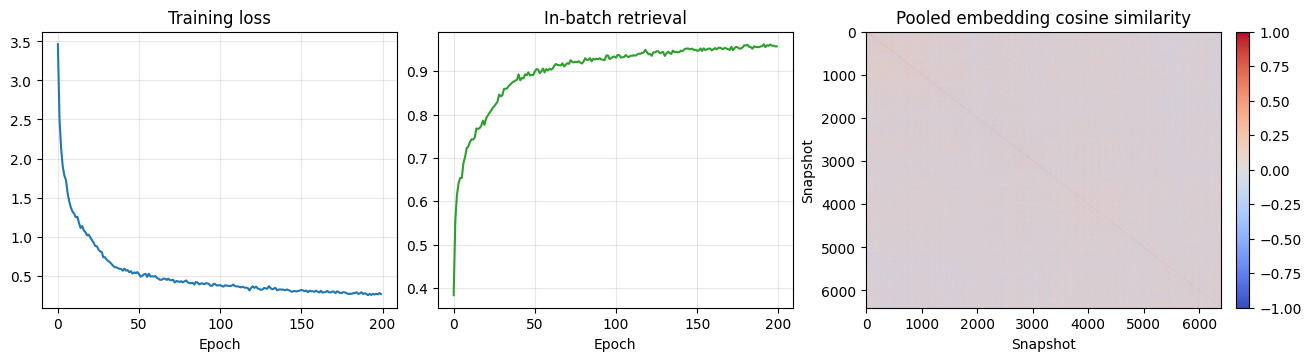

level token shape: (6400, 10, 128)
pooled embedding shape: (6400, 128)
pooled embedding norm mean/std: 1.0 5.0427829023647064e-08


In [ ]:
@jax.jit
def encode_tokens(params, batch):
    return model.apply({"params": params}, batch, return_tokens=True)


@jax.jit
def encode_pooled(params, batch):
    emb = model.apply({"params": params}, batch)
    return l2_normalize(emb)


level_tokens = np.asarray(encode_tokens(state.params, jnp.asarray(x_data)))
pooled_embeddings = np.asarray(encode_pooled(state.params, jnp.asarray(x_data)))
similarity = pooled_embeddings @ pooled_embeddings.T

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5), constrained_layout=True)
axes[0].plot(loss_history, label="InfoNCE loss")
axes[0].set_xlabel("Epoch")
axes[0].set_title("Training loss")
axes[0].grid(True, alpha=0.3)

axes[1].plot(acc_history, label="Retrieval acc", color="tab:green")
axes[1].set_xlabel("Epoch")
axes[1].set_title("In-batch retrieval")
axes[1].grid(True, alpha=0.3)

im = axes[2].imshow(similarity, aspect="auto", cmap="coolwarm", vmin=-1, vmax=1)
axes[2].set_title("Pooled embedding cosine similarity")
axes[2].set_xlabel("Snapshot")
axes[2].set_ylabel("Snapshot")
fig.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)
plt.show()

print("level token shape:", level_tokens.shape)
print("pooled embedding shape:", pooled_embeddings.shape)
print("pooled embedding norm mean/std:", float(np.linalg.norm(pooled_embeddings, axis=1).mean()), float(np.linalg.norm(pooled_embeddings, axis=1).std()))

## 7. Save Artifacts

These outputs are the bridge to the next stage of the paper: saving `VisionAgent` parameters that produce level-centered contextual tokens for reliability/fusion, while keeping the pooled global contrastive representation as an auxiliary diagnostic/training artifact.

In [ ]:
params_path = OUTPUT_DIR / "vision_agent_contrastive.msgpack"
config_path = OUTPUT_DIR / "vision_agent_contrastive_config.json"
tokens_path = OUTPUT_DIR / "vision_level_tokens.npy"
pooled_embeddings_path = OUTPUT_DIR / "vision_pooled_embeddings.npy"
metrics_path = OUTPUT_DIR / "contrastive_training_metrics.npz"

with params_path.open("wb") as f:
    f.write(serialization.to_bytes(state.params))

config = {
    "data_path": DATA_PATH,
    "metadata_path": METADATA_PATH,
    "data_metadata": data_metadata,
    "input_shape": list(vision_obs_all.shape[1:]),
    "n_snapshots": int(vision_obs_all.shape[0]),
    "epochs": int(EPOCHS),
    "batch_size": int(BATCH_SIZE),
    "temperature": float(TEMPERATURE),
    "embed_dim": int(EMBED_DIM),
    "n_levels": int(vision_obs_all.shape[1]),
    "token_shape": [int(vision_obs_all.shape[1]), int(EMBED_DIM)],
    "pooled_embedding_shape": [int(EMBED_DIM)],
    "vision_output": "level_centered_contextual_tokens",
    "pooling": "mean_over_levels",
    "contrastive_objective": "global InfoNCE on VisionAgent default pooled output",
    "architecture": "VisionAgent self branch plus local-context branch",
    "hidden_size": int(HIDDEN_SIZE),
    "context_alpha_init": float(CONTEXT_ALPHA_INIT),
    "learnable_alpha": bool(LEARNABLE_ALPHA),
    "learning_rate": float(LEARNING_RATE),
    "weight_decay": float(WEIGHT_DECAY),
    "jitter_std": float(JITTER_STD),
    "level_keep_prob": float(LEVEL_KEEP_PROB),
    "feature_keep_prob": float(FEATURE_KEEP_PROB),
    "dataset_standardization": False,
    "normalization": "lob_feature_pipeline_only",
    "jax_platforms": os.environ.get("JAX_PLATFORMS"),
    "jax_backend": jax.default_backend(),
    "paper_stage": "Vision Agent level-centered contextual token pretraining with global InfoNCE",
}
with config_path.open("w", encoding="utf-8") as f:
    json.dump(config, f, indent=2)

np.save(tokens_path, level_tokens.astype(np.float32))
np.save(pooled_embeddings_path, pooled_embeddings.astype(np.float32))
np.savez(
    metrics_path,
    loss=np.asarray(loss_history, dtype=np.float32),
    retrieval_acc=np.asarray(acc_history, dtype=np.float32),
)

for path in [params_path, config_path, tokens_path, pooled_embeddings_path, metrics_path]:
    if not path.exists() or path.stat().st_size == 0:
        raise RuntimeError(f"Artifact was not written correctly: {path}")
    print(path, path.stat().st_size, "bytes")



outputs/vision_agent_contrastive.msgpack 605824 bytes
outputs/vision_agent_contrastive_config.json 1601 bytes
outputs/vision_level_tokens.npy 32768128 bytes
outputs/vision_pooled_embeddings.npy 3276928 bytes
outputs/contrastive_training_metrics.npz 2120 bytes
